In [1]:
# loading required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

2026-04-21 17:13:39.550529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776791619.783841      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776791619.853820      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776791620.403739      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776791620.403792      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776791620.403794      55 computation_placer.cc:177] computation placer alr

## Dataset source: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)


## Stage 1. Data Loading & Understanding

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

# first 5 instances
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# basic info of the dataset
features = list(df.columns[:-1])
target = df.columns[-1]
print(f"\n1. Features (X) is: {features}")
print(f"\n2. Target is: {target}")

print(f"\n3. Shape of the dataset is: {df.shape}")


1. Features (X) is: ['review']

2. Target is: sentiment

3. Shape of the dataset is: (50000, 2)


## Stage 2. Text Preprocessing

### 2.1-Mapping target labels

In [4]:
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})
df["sentiment"].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

Inference - Our data is balanced between the two classes

### 2.2-Clean Text Function

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["review"] = df["review"].apply(clean_text)

## Stage 3. Model Training

### 3.1-Splitting Data into training and test sets (80:20)

In [6]:
X = df["review"].values
y = df["sentiment"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 3.2-Tokenization

In [7]:
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

### 3.3-Classification Model Architecture

### LSTM Model

In [8]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_shape=(max_len,)),
    
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1, activation="sigmoid")
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1776791666.434450      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776791666.440509      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,437,185 (5.48 MB)

 Trainable params: 1,436,801 (5.48 MB)

 Non-trainable params: 384 (1.50 KB)

In [9]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [10]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    shuffle=False
)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 204s 196ms/step - accuracy: 0.5132 - loss: 0.7909 - val_accuracy: 0.5024 - val_loss: 0.7075
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 195s 195ms/step - accuracy: 0.5482 - loss: 0.6896 - val_accuracy: 0.5350 - val_loss: 1.6207
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 194s 194ms/step - accuracy: 0.7002 - loss: 0.5746 - val_accuracy: 0.7755 - val_loss: 0.4572
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 196s 196ms/step - accuracy: 0.8057 - loss: 0.4323 - val_accuracy: 0.8149 - val_loss: 0.4175
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 195s 195ms/step - accuracy: 0.8640 - loss: 0.3319 - val_accuracy: 0.8234 - val_loss: 0.4451


### LSTM Model Evaluation

In [11]:
loss, acc = model.evaluate(X_test_pad, y_test)
print(f"Test Loss: {loss:.2f}")
print(f"Test Accuracy: {acc:.2f}")

# Predictions
y_pred_prob = model.predict(X_test_pad)

y_pred = (y_pred_prob > 0.5).astype("int32")

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.8248 - loss: 0.4438
Test Loss: 0.44
Test Accuracy: 0.82
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step
Accuracy Score: 0.8222
              precision    recall  f1-score   support

           0     0.8261    0.8162    0.8211      5000
           1     0.8184    0.8282    0.8233      5000

    accuracy                         0.8222     10000
   macro avg     0.8222    0.8222    0.8222     10000
weighted avg     0.8222    0.8222    0.8222     10000



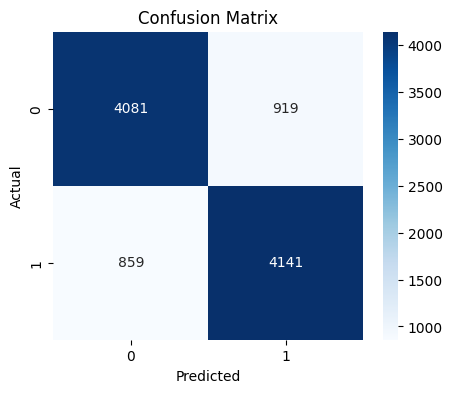

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Stage 4. Prediction Analysis

In [41]:
idx = 100
print(f"\nTest Instance: {X_test[idx]}")
print(f"\nActual class is: {y_test[idx]}")
print(f"\nPredicted class is: {y_test[idx]}")
print(f"\nPrediction probabilities: {y_pred_prob[idx]}")


Test Instance: its a bad movie it seems like there is only police in hk they were not using there gun and this makes me feel like a jacky chans movie all the time they were using their gun to point at the suspect only when they finally use their gun is when they kill each other what a funny movie in the movie its like all the good guys died without a reasonthey story line of the movie also sucks the story jump here and there and bored people but if you wanted to see a bloody movie i think this is only a ok type of movie i think us made zombie movie is more bloodier than this one

Actual class is: 0

Predicted class is: 0

Prediction probabilities: [0.2809302]
